# **Experiment_3D: Perform Logistic Regression with Gradient Descent in a Students Performance Dataset.**

**1. Find cost function, plot the sigmoid curve.**

**2. Evaluate the gradient descent with 3 learning rate**

**3. Find out inference from all three learning rate.**

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LogisticRegression

In [23]:
# Dataset
data = {
    "Hours Studied": [1, 2, 3, 4, 5],
    "Pass or Fail": [0, 0, 0, 1, 1]
}
df = pd.DataFrame(data)
df

,Hours Studied,Pass or Fail
0,1,0
1,2,0
2,3,0
3,4,1
4,5,1


In [24]:
X = np.array(df["Hours Studied"]).reshape(-1, 1)
y = np.array(df["Pass or Fail"])
m = len(y)

In [25]:
# Create Logistic Regression model
model = LogisticRegression()

# Train the model
model.fit(X, y)

LogisticRegression()

In [26]:
# Extract parameters
print("Coefficient (w):", model.coef_)
print("Intercept (b):", model.intercept_)

Coefficient (w): [[1.0470438]]
Intercept (b): [-3.74817743]


In [27]:
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([0, 0, 0, 1, 1])

m = len(y)

In [28]:
# Sigmoid & Cost Function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def cost_function(X, y, w, b):
    m = len(y)
    z = np.dot(X, w) + b
    y_hat = sigmoid(z)
    cost = -(1/m) * np.sum(
        y * np.log(y_hat + 1e-9) + (1 - y) * np.log(1 - y_hat + 1e-9)
    )
    return cost

In [29]:
# Parameters from sklearn model
w_sklearn = model.coef_.flatten()
b_sklearn = model.intercept_[0]

# Compute cost
cost_sklearn = cost_function(X, y, w_sklearn, b_sklearn)

print("Cost:", cost_sklearn)

Cost: 0.27518617491280617


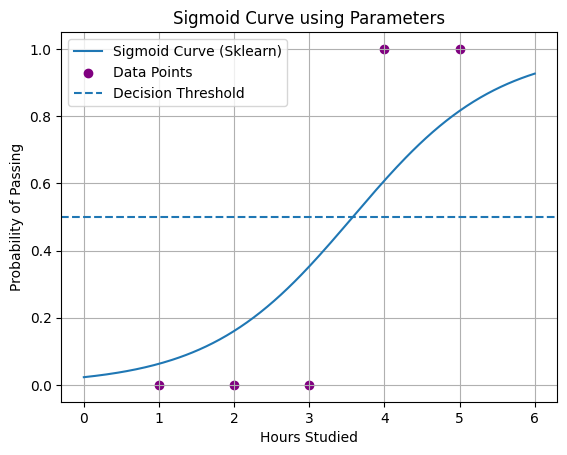

In [30]:
x_vals = np.linspace(0, 6, 200)
z_vals = w_sklearn * x_vals + b_sklearn
y_vals = sigmoid(z_vals)

plt.figure()
plt.plot(x_vals, y_vals, label="Sigmoid Curve (Sklearn)")
plt.scatter(X, y, color='purple', label="Data Points")
plt.axhline(0.5, linestyle='--', label="Decision Threshold")
plt.xlabel("Hours Studied")
plt.ylabel("Probability of Passing")
plt.title("Sigmoid Curve using Parameters")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
def gradient_descent(X, y, lr, iterations):
    w = 0.0
    b = 0.0

    cost_history = []
    w_history = []
    b_history = []

    for _ in range(iterations):
        z = np.dot(X, w) + b
        y_hat = sigmoid(z)

        dw = (1/m) * np.sum((y_hat - y) * X.flatten())
        db = (1/m) * np.sum(y_hat - y)

        w = w - lr * dw
        b = b - lr * db

        cost_history.append(cost_function(X, y, w, b))
        w_history.append(w)
        b_history.append(b)

    return cost_history, w_history, b_history


In [33]:
learning_rates = [0.1, 0.01, 0.001]
iterations = 100

results = {}

for lr in learning_rates:
    cost_hist, w_hist, b_hist = gradient_descent(X, y, lr, iterations)
    results[lr] = {
        "cost": cost_hist,
        "w": w_hist,
        "b": b_hist
    }

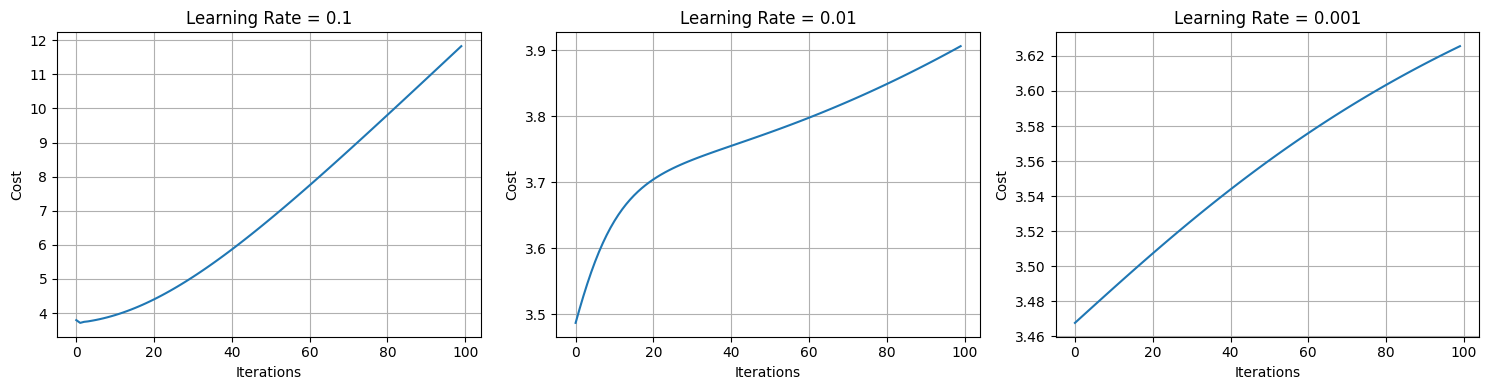

In [34]:
plt.figure(figsize=(15, 4))

for i, lr in enumerate(learning_rates):
    plt.subplot(1, 3, i+1)
    plt.plot(results[lr]["cost"])
    plt.title(f"Learning Rate = {lr}")
    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.grid(True)

plt.tight_layout()
plt.show()


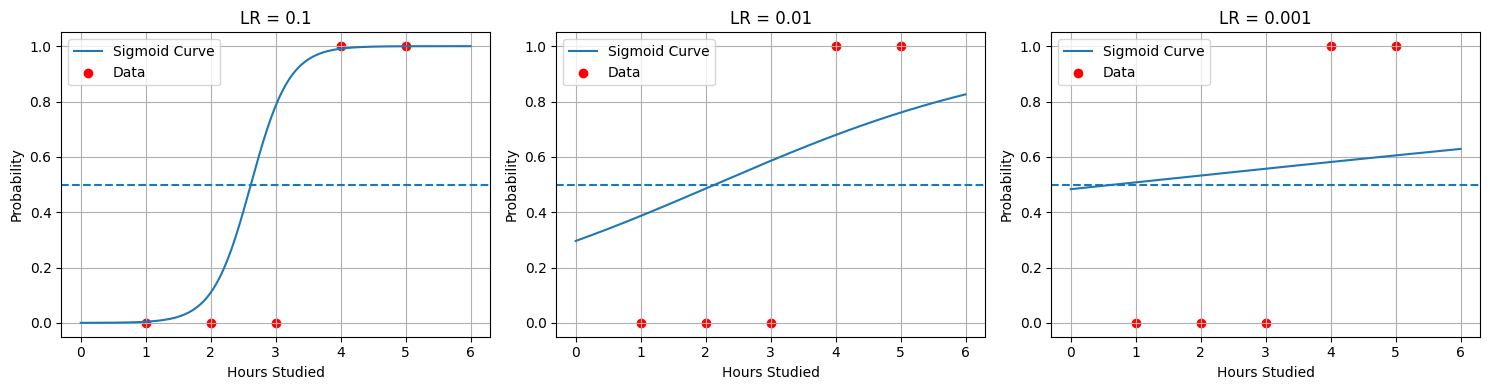

In [35]:
x_curve = np.linspace(0, 6, 200)

plt.figure(figsize=(15, 4))

for i, lr in enumerate(learning_rates):
    w_final = results[lr]["w"][-1]
    b_final = results[lr]["b"][-1]

    z = w_final * x_curve + b_final
    y_curve = sigmoid(z)

    plt.subplot(1, 3, i+1)
    plt.plot(x_curve, y_curve, label="Sigmoid Curve")
    plt.scatter(X, y, color='red', label="Data")
    plt.axhline(0.5, linestyle='--')
    plt.title(f"LR = {lr}")
    plt.xlabel("Hours Studied")
    plt.ylabel("Probability")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

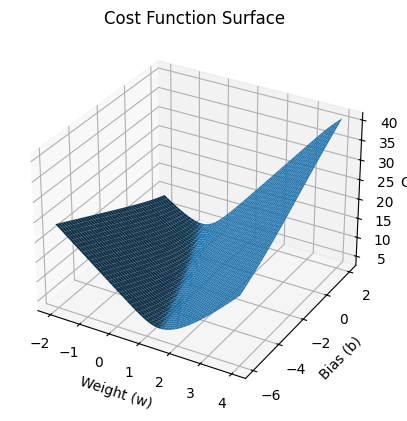

In [37]:
w_range = np.linspace(-2, 4, 50)
b_range = np.linspace(-6, 2, 50)

W, B = np.meshgrid(w_range, b_range)
J = np.zeros(W.shape)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        J[i, j] = cost_function(X, y, W[i, j], B[i, j])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W, B, J)
ax.set_xlabel("Weight (w)")
ax.set_ylabel("Bias (b)")
ax.set_zlabel("Cost")
ax.set_title("Cost Function Surface")
plt.show()

In [39]:
print("Final Parameters using Logistic Regression:")
print("Weight (w) =", w_sklearn)
print("Bias (b)   =", b_sklearn)

print("Final Parameters using Gradient Descent:")
print("Weight (w) =", w_final)
print("Bias (b)   =", b_final)

Final Parameters using Logistic Regression:
Weight (w) = [1.0470438]
Bias (b)   = -3.7481774320466807
Final Parameters using Gradient Descent:
Weight (w) = 0.09891349832099429
Bias (b)   = -0.06702883389300189


In [41]:
# Final Cost using Gradient Descent parameters
final_cost_gd = cost_function(X, y, w_final, b_final)
print("Final Cost (Gradient Descent):", final_cost_gd)

# Final Cost using Sklearn parameters
final_cost_sklearn = cost_function(X, y, w_sklearn, b_sklearn)
print("Final Cost (Sklearn Logistic Regression):", final_cost_sklearn)

Final Cost (Gradient Descent): 3.625553009389776
Final Cost (Sklearn Logistic Regression): 0.27518617491280617


In [42]:
for lr in learning_rates:
    print(f"\nLearning Rate = {lr}")
    print("Final Weight (w):", round(results[lr]["w"][-1], 4))
    print("Final Bias (b):", round(results[lr]["b"][-1], 4))
    print("Final Cost:", round(results[lr]["cost"][-1], 4))


Learning Rate = 0.1
Final Weight (w): 3.3873
Final Bias (b): -8.8709
Final Cost: 11.8252

Learning Rate = 0.01
Final Weight (w): 0.4036
Final Bias (b): -0.8655
Final Cost: 3.9062

Learning Rate = 0.001
Final Weight (w): 0.0989
Final Bias (b): -0.067
Final Cost: 3.6256
